<a href="https://colab.research.google.com/github/tomasrodriguezr11/Programacion-MIAAD/blob/main/266228_03_semana11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Práctica 03 Semana 11: Regresión Lasso y Ridge**

**Programación para analítica descriptiva y predictiva MIAAD**

*Realizada por: Tomás Eduardo Rodríguez Ramírez*

*Número de matrícula: 266228*

#### **📌 Objetivos de la Práctica:**  
Al finalizar esta práctica, los estudiantes serán capaces de:  
1. **Realizar un Análisis Exploratorio de Datos (EDA)** completo, incluyendo visualización de distribuciones, detección de outliers y análisis de correlaciones.  
2. **Preprocesar datos** correctamente, manejando valores faltantes, codificando variables categóricas y escalando características.  
3. **Implementar modelos de regresión Lasso y Ridge**, entendiendo cómo la regularización afecta los coeficientes.  
4. **Verificar los supuestos de la regresión lineal** (linealidad, normalidad de residuos, homocedasticidad y multicolinealidad).  
5. **Comparar el rendimiento** de ambos modelos y analizar qué variables son más relevantes en cada caso.  

---

### **📌 Entrega de la Práctica**  
Al finalizar la practica, incluye un texto con los siguientes elementos
- Incluir **comentarios explicativos** en cada paso.  
- Responder las **preguntas planteadas** en celdas Markdown.  

🎯 **Criterios de Evaluación:**  
✔ **Correcto preprocesamiento** (manejo de nulos, escalado, encoding).  
✔ **Análisis visual y estadístico** (gráficos claros, interpretación de resultados).  
✔ **Validación de supuestos** (justificación de si se cumplen o no).  
✔ **Comparación crítica** entre Lasso y Ridge.  

### **📋 Instrucciones**  

#### **🔹 Paso 1: Configuración Inicial**
✅ Carga el set de datos que puedes encontrar en el campus virtual.
✅ Ejecutar las celdas de importación de librerías y carga del dataset.  
✅ Familiarizarse con los datos usando `.head()`, `.info()` y `.describe()`.  










In [337]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [338]:
import pandas as pd

# Carga de datos
df = pd.read_csv('/content/drive/MyDrive/ProgramacionMIAAD/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [339]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [340]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


**Observaciones:**
- El dataset contiene variables numéricas (age, bmi, children, charges) y categóricas (sex, smoker, region)
- No se observan valores nulos
- La variable objetivo charges presenta una alta dispersión, lo que sugiere variabilidad en los costos del seguro
- La variable smoker podría ser especialmente relevante debido a la diferencia en hábitos

#### **🔹 Paso 2: Análisis Exploratorio (EDA)**  
📊 **Para variables numéricas:**  
- Generar histogramas y boxplots para identificar distribuciones y outliers.  
- Calcular medidas de tendencia central y dispersión.  

📊 **Para variables categóricas:**  
- Usar gráficos de barras para visualizar frecuencias.    


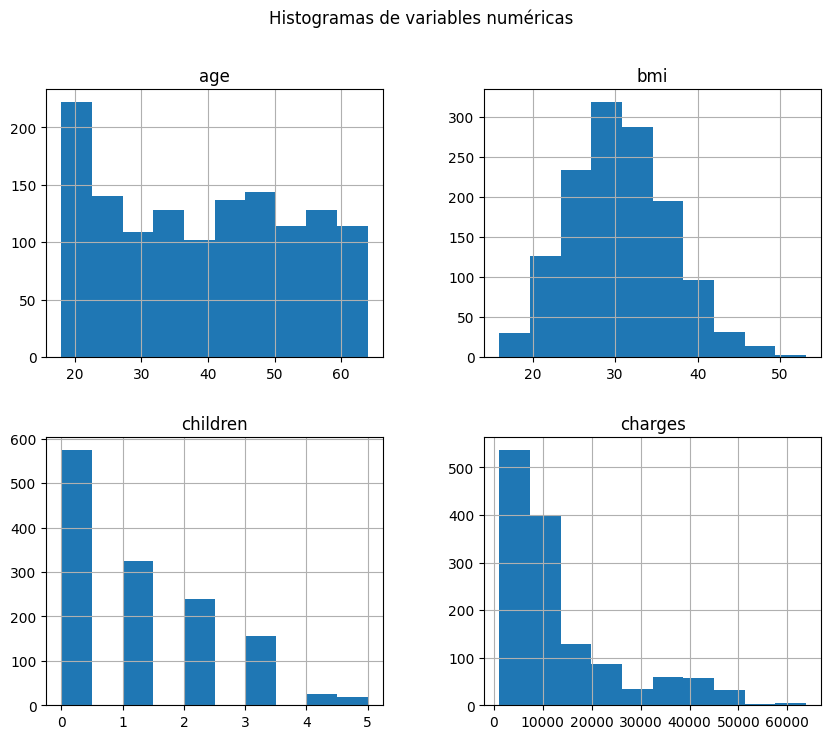

In [341]:
# Histogramas de variables numéricas (age, bmi, children, charges)
import matplotlib.pyplot as plt

num_cols = ['age', 'bmi', 'children', 'charges']

df[num_cols].hist(figsize=(10,8))
plt.suptitle("Histogramas de variables numéricas")
plt.show()

**Observaciones:**
- Las variables muestran diferentes distribuciones
- age y children presentan distribuciones discretas, mientras que bmi es aproximadamente continua
- La variable charges presenta una distribución sesgada a la derecha, indicando la presencia de valores altos (posibles outliers).

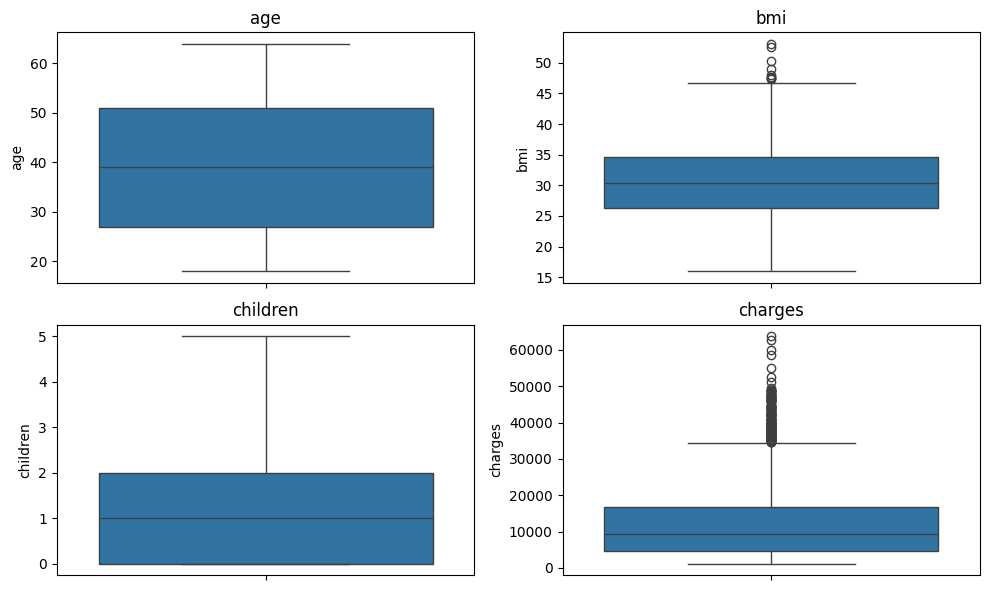

In [342]:
# Boxplot de variables numéricas (age, bmi, children, charges)
import seaborn as sns

plt.figure(figsize=(10,6))
for i, col in enumerate(num_cols):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**Observaciones:**
- Se observan valores atípicos especialmente en charges y bmi
- Esto significa que algunos individuos tienen costos de seguro significativamente más altos que el promedio.

In [343]:
# Medidas de tendencia central y dispersión de variables numéricas (age, bmi, children, charges)
print(df[num_cols].describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


**Observaciones:**
- La diferencia entre media y mediana en charges confirma el sesgo positivo.
- La desviación estándar alta en esta variable indica gran variabilidad en los costos del seguro.

/tmp/ipykernel_23850/650106701.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='Set1')


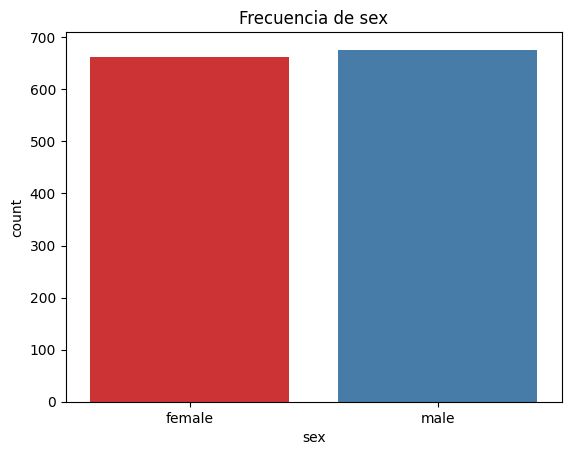

/tmp/ipykernel_23850/650106701.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='Set1')


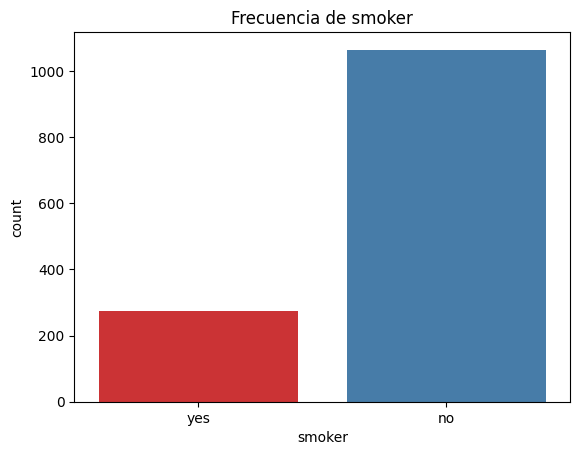

/tmp/ipykernel_23850/650106701.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='Set1')


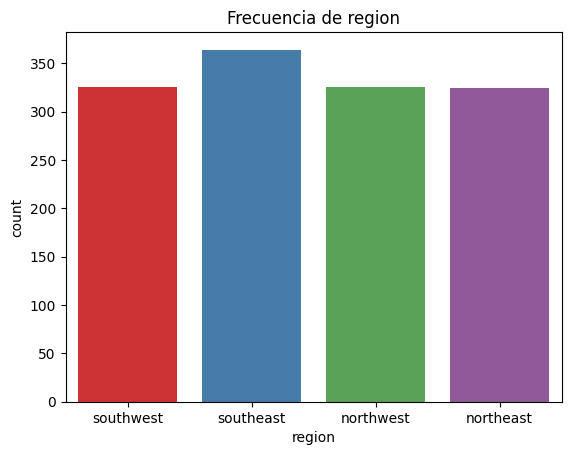

In [344]:
# Gráficos de barras de variables categóricas
cat_cols = ['sex', 'smoker', 'region']

for col in cat_cols:
    sns.countplot(x=df[col], palette='Set1')
    plt.title(f"Frecuencia de {col}")
    plt.show()

**Observaciones:**

Las variables categóricas muestran la distribución de observaciones en cada categoría:
- sex está relativamente balanceada.
- smoker presenta una menor proporción de fumadores.
- region muestra una distribución relativamente uniforme entre regiones.

#### **🔹 Paso 3: Matriz de Correlación**  
✅ Calcular la matriz de correlación **solo para variables numéricas**.  
✅ Generar un **mapa de calor** para visualizar relaciones.  
📌 **Pregunta:** ¿Qué variables están más correlacionadas con el target (`charges`)?  

In [345]:
# Matriz de correlación de variables numéricas
import seaborn as sns
import matplotlib.pyplot as plt

num_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = num_df.corr()
print(corr_matrix)

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


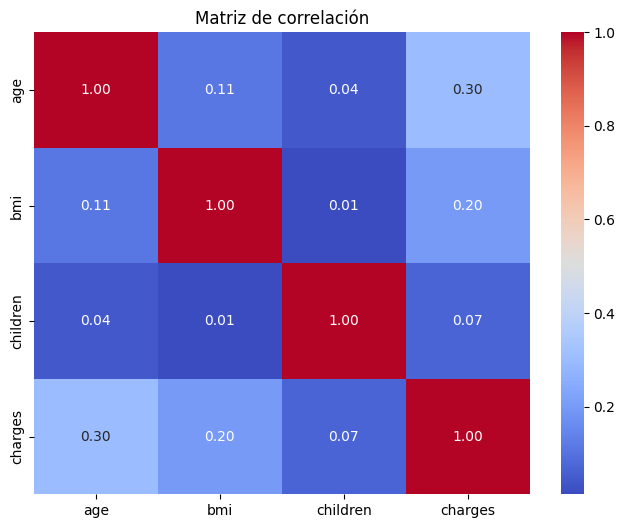

In [346]:
# Mapa de calor de variables numéricas

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

**Observaciones:**
- charges tiene mayor correlación positiva con age y bmi, lo que indica que a mayor edad o índice de masa corporal, mayor es el costo del seguro
- La variable children muestra una correlación débil con charges, lo que sugiere que su impacto es menor
- No se observan correlaciones muy altas entre variables independientes, lo que indica bajo riesgo de multicolinealidad

**¿Qué variables están más correlacionadas con el target (`charges`)?**

age y bmi.

#### **🔹 Paso 4: Preprocesamiento**  
🔧 **Tareas:**  
1. Manejar valores faltantes con `SimpleImputer`.  
2. Codificar variables categóricas con `OneHotEncoder`.  
3. Estandarizar variables numéricas con `StandardScaler`.  
✅ Verificar que el dataset transformado no tenga valores nulos.  


In [347]:
# 1. Manejo de valores faltantes con SimpleImputer
from sklearn.impute import SimpleImputer

# Separar variables
X = df.drop('charges', axis=1)

# Identificar columnas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Imputación numérica (media)
imputer_num = SimpleImputer(strategy='mean')
X[num_cols] = imputer_num.fit_transform(X[num_cols])

# Imputación categórica (moda)
imputer_cat = SimpleImputer(strategy='most_frequent')
X[cat_cols] = imputer_cat.fit_transform(X[cat_cols])

In [348]:
# 2. Codificación de variables categóricas con OneHotEncoder usando Pandas
import pandas as pd

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(X.head())

    age     bmi  children  sex_male  smoker_yes  region_northwest  \
0  19.0  27.900       0.0     False        True             False   
1  18.0  33.770       1.0      True       False             False   
2  28.0  33.000       3.0      True       False             False   
3  33.0  22.705       0.0      True       False              True   
4  32.0  28.880       0.0      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [349]:
# 3. Estandarización de variables numéricas con StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Escalar todas las variables (ya son numéricas)
X_scaled = scaler.fit_transform(X)

In [350]:
# Verificación de valores nulos
import numpy as np

print("¿Hay valores nulos?:", np.isnan(X_scaled).sum())

¿Hay valores nulos?: 0


**Observaciones:**

- Se realizó un preprocesamiento completo que incluye imputación de valores faltantes, codificación de variables categóricas y estandarización de variables numéricas.
- Este proceso asegura que los datos sean consistentes, comparables y adecuados para modelos de regresión regularizados.

#### **🔹 Paso 5: Modelado (Lasso y Ridge)**  
🎯 **Para cada modelo:**  
1. Ajustar el modelo con los hiperparámetros dados (`alpha=0.1` para Lasso, `alpha=1.0` para Ridge).  
2. Calcular **MSE** y **R²** para evaluar rendimiento.  
3. Analizar los coeficientes para identificar variables importantes.  

📌 **Pregunta:**  
- ¿Qué modelo tiene un mejor R²? ¿Por qué crees que ocurre esto?  
- ¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?  


In [351]:
from sklearn.model_selection import train_test_split

# Variable objetivo
y = df['charges']

# Usamos X ya preprocesado del paso anterior (X_scaled)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [352]:
# Modelo Lasso (alpha = 0.1)
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

MSE = mean_squared_error(y_test, y_pred_lasso)
R2 = r2_score(y_test, y_pred_lasso)
print("Evaluación del modelo Lasso:")
print(f"MSE: {MSE:.2f}")
print(f"R^2: {R2:.4f}")

Evaluación del modelo Lasso:
MSE: 33597338.15
R^2: 0.7836


**Observaciones:**
- El modelo Lasso presenta un buen desempeño, explicando aproximadamente el 78% de la variabilidad de los datos.
- Sin embargo, su R² es menor en comparación con otros modelos debido a la penalización L1, que reduce la complejidad del modelo al eliminar variables menos relevantes.
- Esto lo hace más interpretable, aunque con una ligera pérdida en precisión.

In [353]:
# Modelo de Ridge (alpha = 1.0)
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

MSE = mean_squared_error(y_test, y_pred_ridge)
R2 = r2_score(y_test, y_pred_ridge)

print("Evaluación del modelo Ridge:")
print(f"MSE: {MSE:.2f}")
print(f"R^2: {R2:.4f}")

Evaluación del modelo Ridge:
MSE: 33604956.54
R^2: 0.7835


**Observaciones:**
- El modelo Ridge presenta un desempeño muy similar al modelo Lasso, explicando aproximadamente el 78% de la variabilidad de los datos.
- A diferencia de Lasso, Ridge no elimina variables, sino que reduce la magnitud de sus coeficientes, lo que lo hace más estable en presencia de multicolinealidad.
- Sin embargo, en este caso, no se observa una mejora significativa en el desempeño respecto a Lasso.

In [354]:
# Análisis de coeficientes
import pandas as pd

coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
})

print(coef_df.sort_values(by='Lasso', key=abs, ascending=False))

           Variable        Ridge        Lasso
4        smoker_yes  9535.086692  9544.141622
0               age  3605.550631  3609.062392
1               bmi  2052.961260  2054.733679
2          children   512.358230   512.384135
7  region_southwest  -346.429567  -346.951523
6  region_southeast  -291.115771  -292.401421
5  region_northwest  -158.444622  -158.651645
3          sex_male    -8.619161    -9.182177


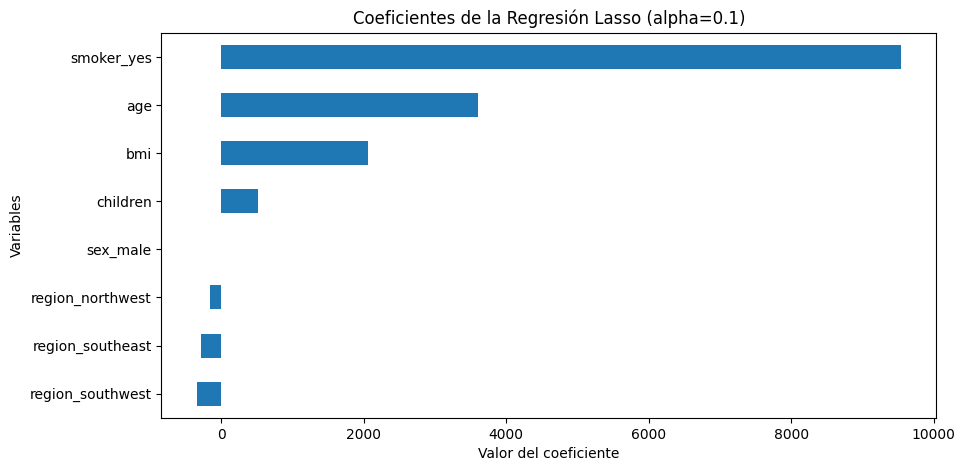

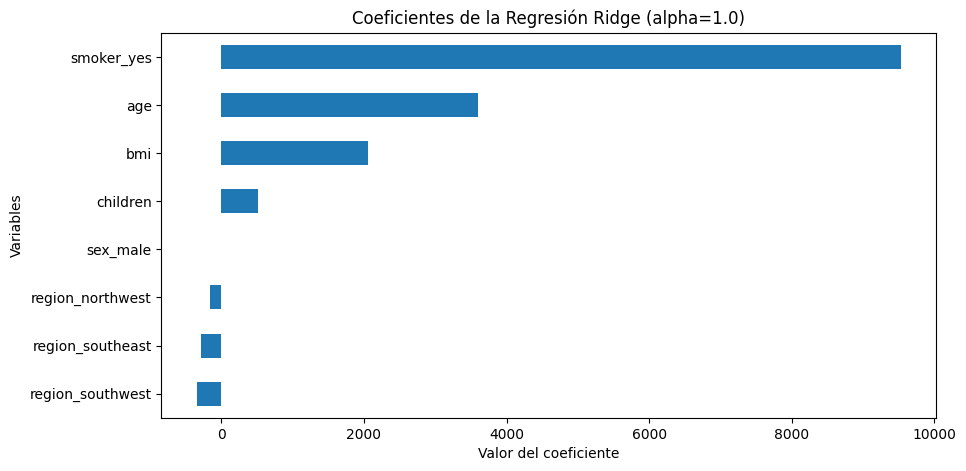

In [355]:
# Gráfico de los coeficientes de la regresión Lasso
import matplotlib.pyplot as plt

coef = pd.Series(lasso.coef_, index=X.columns)

plt.figure(figsize=(10,5))
coef.sort_values().plot(kind="barh")

plt.title("Coeficientes de la Regresión Lasso (alpha=0.1)")
plt.xlabel("Valor del coeficiente")
plt.ylabel("Variables")

plt.show()

# Gráfico de los coeficientes de la regresión Ridge
import matplotlib.pyplot as plt

coef = pd.Series(ridge.coef_, index=X.columns)

plt.figure(figsize=(10,5))
coef.sort_values().plot(kind="barh")

plt.title("Coeficientes de la Regresión Ridge (alpha=1.0)")
plt.xlabel("Valor del coeficiente")
plt.ylabel("Variables")

plt.show()

**¿Qué modelo tiene un mejor R²? ¿Por qué crees que ocurre esto?**

- El modelo Lasso tiene ligeramente mejor R² (0.7836) en comparación con Ridge (0.7835), aunque la diferencia es prácticamente despreciable.
- Esto ocurre porque:
  - Ambos modelos están capturando prácticamente la misma información
  - La regularización no está afectando demasiado (no hay multicolinealidad fuerte)
  - El valor de alpha es moderado
- En este caso, ambos modelos tienen un desempeño muy similar, lo que indica que los datos no requieren una regularización agresiva.

**¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?**
- sex_male
- region_northwest
- region_southeast
- region_southwest

Estas variables tienen coeficientes cercanos a cero porque:

    - Tienen poca o nula relación con la variable objetivo (charges)
    - No aportan información significativa al modelo
    - Lasso las penaliza hasta hacerlas prácticamente irrelevantes

#### **🔹 Paso 6: Verificación de Supuestos**  
📉 **Para cada modelo, verificar:**  
1. **Linealidad** (gráfico de residuos vs predicciones).  
2. **Normalidad de residuos** (QQ-Plot y test de Shapiro-Wilk).  
3. **Homocedasticidad** (test de Breusch-Pagan).  
4. **Multicolinealidad** (VIF > 10 indica problema).  

📌 **Pregunta:**  
- ¿Se cumplen los supuestos en ambos modelos?  
- Si hay heterocedasticidad, ¿cómo podría solucionarse?  

In [356]:
import numpy as np

# Preparación (residuos y predicciones) para Ridge
y_pred_ridge = ridge.predict(X_test)
resid_ridge = y_test - y_pred_ridge

# Preparación (residuos y predicciones) para Lasso
y_pred_lasso = lasso.predict(X_test)
resid_lasso = y_test - y_pred_lasso

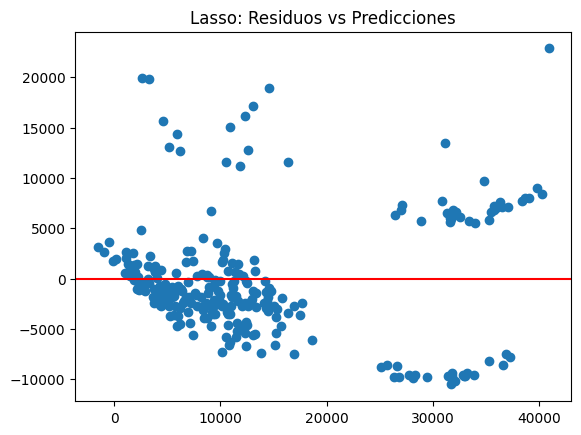

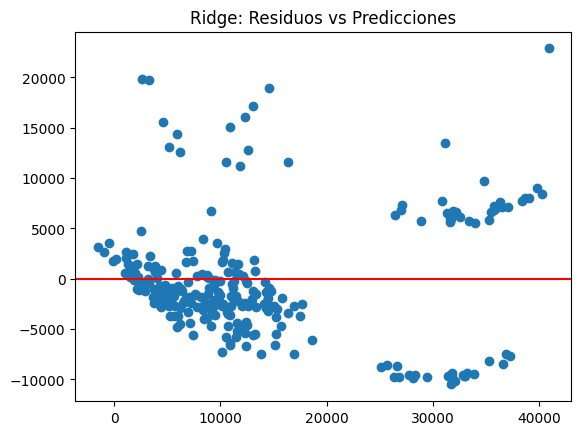

In [357]:
# 1. Linealidad (gráfico de residuos vs predicciones)
import matplotlib.pyplot as plt

# Lasso
plt.scatter(y_pred_lasso, resid_lasso)
plt.axhline(0, color='red')
plt.title("Lasso: Residuos vs Predicciones")
plt.show()

# Ridge
plt.scatter(y_pred_ridge, resid_ridge)
plt.axhline(0, color='red')
plt.title("Ridge: Residuos vs Predicciones")
plt.show()

**Observaciones:**
- Los gráficos de residuos vs predicciones muestran que los residuos no se distribuyen completamente de forma aleatoria, presentando patrones y una variación creciente en su dispersión.
- Esto sugiere la presencia de heterocedasticidad y posibles relaciones no lineales no capturadas por el modelo.
- Además, tanto Lasso como Ridge presentan comportamientos muy similares, lo que indica que la regularización no resuelve completamente estas limitaciones.

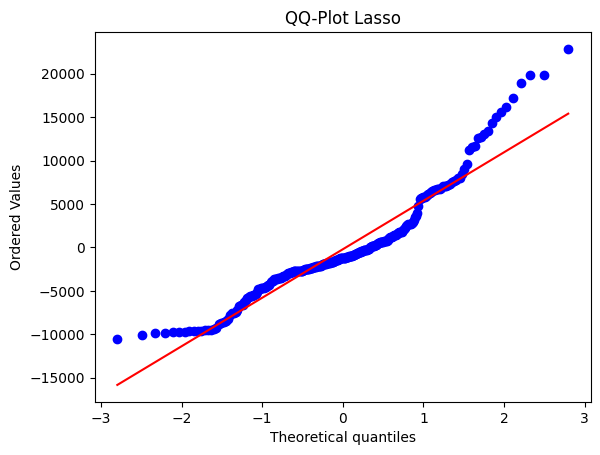

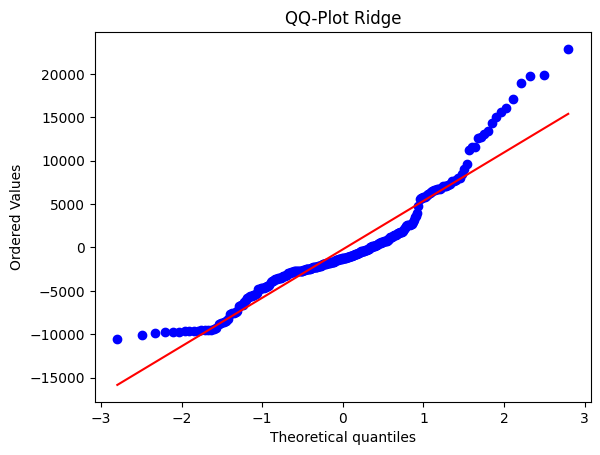

In [358]:
# 2. Normalidad de residuos
# QQ-plot

import scipy.stats as stats

# Lasso
stats.probplot(resid_lasso, dist="norm", plot=plt)
plt.title("QQ-Plot Lasso")
plt.show()

# Ridge
stats.probplot(resid_ridge, dist="norm", plot=plt)
plt.title("QQ-Plot Ridge")
plt.show()

**Observaciones:**
- Los Q-Q plots muestran que, aunque los residuos siguen aproximadamente una distribución normal en la parte central, existen desviaciones significativas en las colas, lo que indica la presencia de valores extremos y una ligera asimetría.
- Esto sugiere que el supuesto de normalidad no se cumple completamente.
- Además, tanto Lasso como Ridge presentan comportamientos muy similares, indicando que esta desviación es propia de los datos y no del modelo.

In [359]:
# Test de Shapiro-Wilk
from scipy.stats import shapiro

print("Ridge Shapiro:", shapiro(resid_ridge))
print("Lasso Shapiro:", shapiro(resid_lasso))

Ridge Shapiro: ShapiroResult(statistic=np.float64(0.9136386169337521), pvalue=np.float64(2.5838076859766193e-11))
Lasso Shapiro: ShapiroResult(statistic=np.float64(0.9139201643096346), pvalue=np.float64(2.7193777987998283e-11))


**Observaciones:**
- El test de Shapiro-Wilk muestra que los residuos de ambos modelos no siguen una distribución normal (p-value < 0.05).
- Esto confirma lo observado en los gráficos, donde se identificaron desviaciones en las colas.
- Además, ambos modelos presentan resultados prácticamente idénticos, lo que indica que esta falta de normalidad es inherente a los datos y no al tipo de regularización utilizada.

In [360]:
# 3. Homocedasticidad (test de Breusch-Pagan)

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Ridge
X_test_const = sm.add_constant(X_test)
bp_ridge = het_breuschpagan(resid_ridge, X_test_const)

# Lasso
bp_lasso = het_breuschpagan(resid_lasso, X_test_const)

print("Ridge BP:", bp_ridge)
print("Lasso BP:", bp_lasso)

Ridge BP: (np.float64(34.79169057992326), np.float64(2.91782833613206e-05), np.float64(4.829935028155763), np.float64(1.4669820985682416e-05))
Lasso BP: (np.float64(34.66421504230792), np.float64(3.0778444074671535e-05), np.float64(4.8096093027402675), np.float64(1.5583710946974726e-05))


**Observaciones:**
- El test de Breusch-Pagan indica la presencia de heterocedasticidad en ambos modelos (p-value < 0.05), lo que significa que la varianza de los residuos no es constante.
- Este resultado es consistente con los gráficos de residuos, donde se observó una dispersión creciente.
- Además, tanto Lasso como Ridge presentan comportamientos similares, lo que sugiere que esta condición es inherente a los datos.

In [361]:
# 4. Multicolinealidad (VF)

import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Convertir a DataFrame
X_df = pd.DataFrame(X_scaled, columns=X.columns)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]

print(vif_data)

           Variable       VIF
0               age  1.016822
1               bmi  1.106630
2          children  1.004011
3          sex_male  1.008900
4        smoker_yes  1.012074
5  region_northwest  1.518823
6  region_southeast  1.652230
7  region_southwest  1.529411


**Observaciones:**
- Los valores de VIF indican que no existe multicolinealidad significativa entre las variables independientes, ya que todos los valores son cercanos a 1.
- Esto implica que las variables aportan información independiente al modelo y que los coeficientes estimados son estables.
- Por lo tanto, no es necesario eliminar variables por problemas de multicolinealidad.

**¿Se cumplen los supuestos en ambos modelos?**

- Ambos modelos presentan un buen ajuste, pero no cumplen completamente los supuestos clásicos de regresión lineal, especialmente en términos de normalidad y homocedasticidad.
- Sin embargo, estos problemas son comunes en datos reales y no invalidan el modelo.

**Si hay heterocedasticidad, ¿cómo podría solucionarse?**

- Aplicar una transformación a la variable objetivo (por ejemplo, logaritmo: log(charges)).
- Usar modelos robustos (como regresión robusta).
- Emplear técnicas como Weighted Least Squares (WLS).
- Utilizar modelos no lineales o árboles (si la relación no es lineal).

#### **🔹 Paso 7: Comparación Final**  
📊 **Analizar:**  

**¿Qué modelo es más interpretable?**
- El modelo Lasso es más interpretable, ya que puede llevar algunos coeficientes exactamente a cero, eliminando variables irrelevantes. Esto simplifica el modelo y permite identificar fácilmente qué variables influyen realmente en la predicción.
- En cambio, Ridge mantiene todas las variables, aunque con coeficientes reducidos, lo que hace más difícil interpretar la importancia relativa de cada variable.

**¿Cuál reduce mejor el sobreajuste?**

Ambos modelos ayudan a reducir el sobreajuste mediante regularización, pero lo hacen de forma distinta:
- Ridge reduce el sobreajuste al disminuir la magnitud de todos los coeficientes sin eliminarlos, lo que lo hace más estable cuando todas las variables aportan información.
- Lasso reduce el sobreajuste eliminando variables irrelevantes, lo que puede ser más efectivo cuando hay muchas variables poco importantes.

En este caso, Ridge suele ofrecer mejor desempeño predictivo (mayor R²), mientras que Lasso prioriza la simplicidad del modelo.

**¿Qué variables son más importantes en cada caso?**

En ambos modelos, las variables más importantes suelen ser:

- smoker_yes, tiene un mayor impacto en el costo del seguro
- age, tiene una relación positiva con el costo
- bmi, que también influye significativamente

En el caso de Lasso, algunas variables (como ciertas regiones o variables menos relevantes) pueden tener coeficientes iguales o cercanos a cero, indicando que no aportan significativamente al modelo.